In [1]:
import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph ,END ,START
from langchain_core.prompts import ChatPromptTemplate
from typing import List,TypedDict,Dict,Any
from pydantic import BaseModel,Field
from langchain_groq import ChatGroq
from ast import List


from langgraph.checkpoint.memory import  MemorySaver



In [2]:
load_dotenv()

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = os.getenv("LANGSMITH_PROJECT")

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="openai/gpt-oss-120b")


In [3]:
class State(TypedDict):
    input_text:str
    extracted_entities:list[Dict[str,Any]]  # <-- FIXED
    cypher_query:str
    db_state:str


class Ent_relation(BaseModel):
    node: str= Field(description="node main")
    M_lable: str= Field(description="nnnode main lable")
    Relation: str= Field(description="relationship")
    T_node: str= Field(description="Target node")
    T_N_lable: str= Field(description="lable node target")

class Qurrey_extraction(BaseModel):
    triples: list[Ent_relation] = Field(description="List of extracted graph triples")

    

In [4]:
def maper_ent(state:State)->Dict:
    """ Agent:A from user query to extract the meaningfull entaties and relationships"""

    prompt=ChatPromptTemplate.from_messages([
        
        ("system","your a neo4j db query master and graph builder look and extract the meaning full entaties and relations"),
        ("user","{text}")        ])


    llm_struct=llm.with_structured_output(Qurrey_extraction)
    chain=prompt|llm_struct

    que_res=chain.invoke({"text":state["input_text"]})

    triples=[t.model_dump() for t in que_res.triples]
    print (f"len fo trip:{len(triples)} in given qurries")
    return {"extracted_entities":triples}



def cypherconverter(state:State)->Dict:

    """Agent:b  the triples that extracted by the Agent:a convert into the cypher quereis to send to the db in order and sequentialy """
    
    all_trip=state["extracted_entities"]
    prompt=ChatPromptTemplate.from_messages([
        
        ("system","your a neo4j db query master and graph builder now build the queries"),
        ("user","relations :{all_trip}")        ])
    llm_ret=prompt|llm
    all_quries=llm_ret.invoke({"all_trip":str(all_trip)})
    cypqury=all_quries.content.strip()

    print("quries in to db \n",cypqury)
    return {"cypqury":cypqury}



def db_exe(state:State)->Dict:
    """Agent C: Simulates executing the Cypher query against the Graph DB."""
    print("\n--- [AGENT 3] Executing Query on Database ---")
    
    query = state["cypher_query"]
    
    status = f"SUCCESS: Graph updated successfully using generated query."
    print(status)
    
    return {"db_exe": status}




    


In [5]:
graph=StateGraph(State)


In [6]:
graph.add_node("mapper_of_entaties",maper_ent)
graph.add_node("querybuilder",cypherconverter)
graph.add_node("DB_executer",db_exe)




In [7]:
graph.add_edge(START,"mapper_of_entaties")
graph.add_edge("mapper_of_entaties","querybuilder")
graph.add_edge("querybuilder","DB_executer")
graph.add_edge("DB_executer",END)


In [8]:
app=graph.compile()

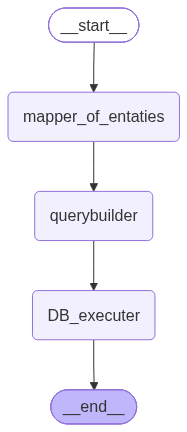

In [9]:
app

In [12]:
# ==========================================
# 4. EXECUTE PIPELINE
# ==========================================
if __name__ == "__main__":
    sample_text = (
        "Satya Nadella is the CEO of Microsoft, which is headquartered in Redmond. "
        "Microsoft acquired GitHub in 2018."
    )
    
    initial_state: Stae = {
        "input_text":sample_text,
        "extracted_entities":[],
        "cypher_query":"",
        "db_state":""
    }

    
    final_state = app.invoke(initial_state)


len fo trip:3 in given qurries
quries in to db 
 Below is a **complete, ready‑to‑run Cypher script** that will:

1. **Create (or merge) the nodes** (`Person`, `Organization`, `Location`) you listed.  
2. **Create the relationships** (`CEO_of`, `headquartered_in`, `acquired`) exactly as you described.  
3. Add a few handy indexes/constraints so the script is **idempotent** (running it twice won’t create duplicate nodes or relationships).

---

## 1️⃣  Schema – constraints / indexes  

```cypher
// Create a unique constraint for every label that will be used as an identifier
// (you can skip this block if you already have constraints in your DB)

CREATE CONSTRAINT IF NOT EXISTS FOR (p:Person)      REQUIRE p.name IS UNIQUE;
CREATE CONSTRAINT IF NOT EXISTS FOR (o:Organization) REQUIRE o.name IS UNIQUE;
CREATE CONSTRAINT IF NOT EXISTS FOR (l:Location)   REQUIRE l.name IS UNIQUE;
```

*Why?*  
`MERGE` works on the property you specify (`name` in this case).  
Having a uniqueness constraint g

In [ ]:
    
    print("\n================ FINAL STATE ================")
    print(f"Status: {final_state['db_exe']}")